## Amazon Product Review Classification Using NLP

In [1]:
import pandas as pd
import numpy as np
import nltk                                                       
from nltk.tokenize import word_tokenize                           
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer,WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer
nltk.download('punk')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Error loading punk: Package 'punk' not found in index
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\dines\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\dines\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

####  Import Dataset

In [2]:
df=pd.read_csv("D:\Data Science With Python\dataset\Deep Learning\Amazon-Product-Reviews - Amazon Product Review (1).csv")
df.head()

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
C:\Users\dines\AppData\Local\Temp\ipykernel_2276\3840762431.py:1: SyntaxWarning: invalid escape sequence '\D'
  df=pd.read_csv("D:\Data Science With Python\dataset\Deep Learning\Amazon-Product-Reviews - Amazon Product Review (1).csv")


,marketplace,customer_id,review_id,product_id,product_parent,product_title,product_category,star_rating,helpful_votes,total_votes,vine,verified_purchase,review_headline,review_body,review_date,sentiment
0,US,11555559,R1QXC7AHHJBQ3O,B00IKPX4GY,2693241,"Fire HD 7, 7"" HD Display, Wi-Fi, 8 GB",PC,5,0,0,N,Y,Five Stars,Great love it,2015-08-31,1
1,US,31469372,R175VSRV6ZETOP,B00IKPYKWG,2693241,"Fire HD 7, 7"" HD Display, Wi-Fi, 8 GB",PC,3,0,0,N,N,Lots of ads Slow processing speed Occasionally...,Lots of ads<br />Slow processing speed<br />Oc...,2015-08-31,0
2,US,26843895,R2HRFF78MWGY19,B00IKPW0UA,2693241,"Fire HD 7, 7"" HD Display, Wi-Fi, 8 GB",PC,5,0,0,N,Y,Well thought out device,Excellent unit. The versatility of this table...,2015-08-31,1
3,US,19844868,R8Q39WPKYVSTX,B00LCHSHMS,2693241,"Fire HD 7, 7"" HD Display, Wi-Fi, 8 GB",PC,4,0,0,N,N,Not all apps/games we were looking forward to ...,I bought this on Amazon Prime so I ended up bu...,2015-08-31,1
4,US,1189852,R3RL4C8YP2ZCJL,B00IKPZ5V6,2693241,"Fire HD 7, 7"" HD Display, Wi-Fi, 8 GB",PC,5,0,0,N,Y,Five Stars,All Amazon products continue to meet my expect...,2015-08-31,1


#### Preprocessing 

In [3]:
df.isnull().sum()

marketplace          0
customer_id          0
review_id            0
product_id           0
product_parent       0
product_title        0
product_category     0
star_rating          0
helpful_votes        0
total_votes          0
vine                 0
verified_purchase    0
review_headline      2
review_body          4
review_date          0
sentiment            0
dtype: int64

In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df['sentiment'].value_counts()

sentiment
1    25767
0     5079
Name: count, dtype: int64

In [6]:
df.shape

(30846, 16)

####  Delete Unnecessary Columns

In [7]:
df.drop(columns=['marketplace', 'customer_id', 'review_id', 'product_id',
       'product_parent', 'product_title', 'product_category', 'star_rating',
       'helpful_votes', 'total_votes', 'vine', 'verified_purchase'],inplace=True)

In [8]:
ps=PorterStemmer()
lemma=WordNetLemmatizer()
stopwords=set(stopwords.words('english'))

#### Text Preprocessing

I take 2 columns for preprocessing [review body,review headline]

1.Word Tokenize <br>
2.Stop Words <br>
3.Stemming <br>
4.Lemmatitation<br>

In [9]:
df['review_headline'].astype(str)
df['review_body'].astype(str)

0                                            Great love it
1        Lots of ads<br />Slow processing speed<br />Oc...
2        Excellent unit.  The versatility of this table...
3        I bought this on Amazon Prime so I ended up bu...
4        All Amazon products continue to meet my expect...
                               ...                        
30841    [[VIDEOID:moP3B6GS5RL8LY]]I purchased the orig...
30842    I'm writing this review with the benefit of be...
30843    I purchased this Kindle for my grandma, becaus...
30844    I bought my tablet Fire HD 7 at Best Buy on th...
30845    Am impressive piece of hardware for the $. No ...
Name: review_body, Length: 30846, dtype: object

In [10]:
df['review_headline'] = df['review_headline'].astype(str)
df['review_body'] = df['review_body'].astype(str)

df['headline_tokens'] = df['review_headline'].apply(word_tokenize)
df['body_tokens'] = df['review_body'].apply(word_tokenize)

In [11]:
df['st1']=df['headline_tokens'].apply(lambda x:[word.lower()for word in x if word.lower() not in stopwords and word.isalpha()])
df['st2']=df['body_tokens'].apply(lambda x:[word.lower()for word in x if word.lower() not in stopwords and word.isalpha()])

In [12]:
df['stem1']=df['st1'].apply(lambda x:[ps.stem(word) for word in x])
df['stem2']=df['st2'].apply(lambda x:[ps.stem(word) for word in x])

In [13]:
df['lemma1']=df['st1'].apply(lambda x:[lemma.lemmatize(word) for word in x])
df['lemma2']=df['st2'].apply(lambda x:[lemma.lemmatize(word) for word in x])

In [14]:
df['processed_head']=df['lemma1'].apply(lambda x:" ".join(x))
df['processed_body']=df['lemma2'].apply(lambda x:" ".join(x))

#### Text Preprocessed

In [15]:
df.head()

,review_headline,review_body,review_date,sentiment,headline_tokens,body_tokens,st1,st2,stem1,stem2,lemma1,lemma2,processed_head,processed_body
0,Five Stars,Great love it,2015-08-31,1,"[Five, Stars]","[Great, love, it]","[five, stars]","[great, love]","[five, star]","[great, love]","[five, star]","[great, love]",five star,great love
1,Lots of ads Slow processing speed Occasionally...,Lots of ads<br />Slow processing speed<br />Oc...,2015-08-31,0,"[Lots, of, ads, Slow, processing, speed, Occas...","[Lots, of, ads, <, br, /, >, Slow, processing,...","[lots, ads, slow, processing, speed, occasiona...","[lots, ads, br, slow, processing, speed, br, o...","[lot, ad, slow, process, speed, occasion, shut...","[lot, ad, br, slow, process, speed, br, occasi...","[lot, ad, slow, processing, speed, occasionall...","[lot, ad, br, slow, processing, speed, br, occ...",lot ad slow processing speed occasionally shut...,lot ad br slow processing speed br occasionall...
2,Well thought out device,Excellent unit. The versatility of this table...,2015-08-31,1,"[Well, thought, out, device]","[Excellent, unit, ., The, versatility, of, thi...","[well, thought, device]","[excellent, unit, versatility, tablet, besides...","[well, thought, devic]","[excel, unit, versatil, tablet, besid, competi...","[well, thought, device]","[excellent, unit, versatility, tablet, besides...",well thought device,excellent unit versatility tablet besides comp...
3,Not all apps/games we were looking forward to ...,I bought this on Amazon Prime so I ended up bu...,2015-08-31,1,"[Not, all, apps/games, we, were, looking, forw...","[I, bought, this, on, Amazon, Prime, so, I, en...","[looking, forward, using, compatible, tablet, ...","[bought, amazon, prime, ended, buying, one, ca...","[look, forward, use, compat, tablet, enjoy, th...","[bought, amazon, prime, end, buy, one, camera,...","[looking, forward, using, compatible, tablet, ...","[bought, amazon, prime, ended, buying, one, ca...",looking forward using compatible tablet enjoyi...,bought amazon prime ended buying one camera ok...
4,Five Stars,All Amazon products continue to meet my expect...,2015-08-31,1,"[Five, Stars]","[All, Amazon, products, continue, to, meet, my...","[five, stars]","[amazon, products, continue, meet, expectations]","[five, star]","[amazon, product, continu, meet, expect]","[five, star]","[amazon, product, continue, meet, expectation]",five star,amazon product continue meet expectation


#### CountVectorizer
   CountVectorizer converts text into numeric vectors by counting word occurrences. It is simple, fast, and effective for sentiment analysis when using classical machine learning models.


In [16]:
cv1=CountVectorizer()
cv2=CountVectorizer()
vec1=cv1.fit_transform(df['processed_head'])
vec2=cv2.fit_transform(df['processed_body'])

vec1 is processed head .Its shape (30846, 3946)

In [17]:
vec1

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 84766 stored elements and shape (30846, 3946)>

vec2 is processed head .Its shape (30846, 12314)

In [18]:
vec2

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 422257 stored elements and shape (30846, 12314)>

hstack() horizontally combines multiple sparse matrices into one large feature matrix. This lets you merge features from vec1 and vec2 so your model can learn from both text inputs together.

In [ ]:
from scipy.sparse import hstack       #hstack = concatenate

input= hstack([vec1, vec2])


I combine 2 vector and i name it as "input".Now its shape is (30846, 16260)

In [20]:
input

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 507023 stored elements and shape (30846, 16260)>

#### Model Training 

In [21]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(input,df['sentiment'],test_size=0.2,random_state=43)

In [22]:
input.shape

(30846, 16260)

In [23]:
df['sentiment'].shape

(30846,)

####  Machine Learning Algorithm 

#### Logistic Regression 

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score
lr=LogisticRegression()
lr.fit(x_train,y_train)
y_pred=lr.predict(x_test)

print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))
print(accuracy_score(y_test,y_pred))

[[ 729  309]
 [ 174 4958]]
              precision    recall  f1-score   support

           0       0.81      0.70      0.75      1038
           1       0.94      0.97      0.95      5132

    accuracy                           0.92      6170
   macro avg       0.87      0.83      0.85      6170
weighted avg       0.92      0.92      0.92      6170

0.9217179902755267


In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score
lr=LogisticRegression()
lr.fit(x_test,y_test)
y_pred=lr.predict(x_test)

print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))
print(accuracy_score(y_test,y_pred))

[[ 981   57]
 [   7 5125]]
              precision    recall  f1-score   support

           0       0.99      0.95      0.97      1038
           1       0.99      1.00      0.99      5132

    accuracy                           0.99      6170
   macro avg       0.99      0.97      0.98      6170
weighted avg       0.99      0.99      0.99      6170

0.9896272285251215


#### Multinomial Naive Bayes

In [26]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score
lr=MultinomialNB()
lr.fit(x_train,y_train)
y_pred=lr.predict(x_test)

print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))
print(accuracy_score(y_test,y_pred))

[[ 746  292]
 [ 267 4865]]
              precision    recall  f1-score   support

           0       0.74      0.72      0.73      1038
           1       0.94      0.95      0.95      5132

    accuracy                           0.91      6170
   macro avg       0.84      0.83      0.84      6170
weighted avg       0.91      0.91      0.91      6170

0.9094003241491085


In [27]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score
lr=MultinomialNB()
lr.fit(x_test,y_test)
y_pred=lr.predict(x_test)

print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))
print(accuracy_score(y_test,y_pred))

[[ 718  320]
 [  70 5062]]
              precision    recall  f1-score   support

           0       0.91      0.69      0.79      1038
           1       0.94      0.99      0.96      5132

    accuracy                           0.94      6170
   macro avg       0.93      0.84      0.87      6170
weighted avg       0.94      0.94      0.93      6170

0.9367909238249594


#### Complement Naive Bayes

In [28]:
from sklearn.naive_bayes import ComplementNB
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score
lr=ComplementNB()
lr.fit(x_train,y_train)
y_pred=lr.predict(x_test)

print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))
print(accuracy_score(y_test,y_pred))

[[ 849  189]
 [ 368 4764]]
              precision    recall  f1-score   support

           0       0.70      0.82      0.75      1038
           1       0.96      0.93      0.94      5132

    accuracy                           0.91      6170
   macro avg       0.83      0.87      0.85      6170
weighted avg       0.92      0.91      0.91      6170

0.9097244732576986


In [29]:
from sklearn.naive_bayes import ComplementNB
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score
lr=ComplementNB()
lr.fit(x_test,y_test)
y_pred=lr.predict(x_test)

print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))
print(accuracy_score(y_test,y_pred))

[[ 828  210]
 [ 113 5019]]
              precision    recall  f1-score   support

           0       0.88      0.80      0.84      1038
           1       0.96      0.98      0.97      5132

    accuracy                           0.95      6170
   macro avg       0.92      0.89      0.90      6170
weighted avg       0.95      0.95      0.95      6170

0.9476499189627229


In traditional machine learning model it performs well.And now i trying neural network to get more accurate results 

#### Deep Learning

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras import regularizers        #Prevent Overfit

In [ ]:
X = input.toarray()   # if input is a scipy sparse matrix
y = df['sentiment'].values

In [32]:
model = Sequential([
    Dense(256, activation='relu', input_shape=(16260,),
          kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.5),

    Dense(128, activation='relu',
          kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.4),

    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',                   # (Adaptive Moment Estimation).It automatically adjusts learning rate during training.fast,popular
    loss='binary_crossentropy',         # (output is binary (0 or 1))
    metrics=['accuracy',]
)

history = model.fit(
    X, y,
    epochs=10,                          # The model will go through the entire dataset 10 times.
    batch_size=32,                      # Model will train 32 samples at a time instead of the whole dataset.
    validation_split=0.2,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=2,
            restore_best_weights=True   # After stopping, use the best version of the model
        )
    ]
)


d:\Data Science With Python\.venv\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
772/772 ━━━━━━━━━━━━━━━━━━━━ 41s 50ms/step - accuracy: 0.9153 - loss: 0.3370 - val_accuracy: 0.9240 - val_loss: 0.3132
Epoch 2/10
772/772 ━━━━━━━━━━━━━━━━━━━━ 39s 50ms/step - accuracy: 0.9335 - loss: 0.3011 - val_accuracy: 0.9214 - val_loss: 0.3297
Epoch 3/10
772/772 ━━━━━━━━━━━━━━━━━━━━ 45s 59ms/step - accuracy: 0.9371 - loss: 0.2989 - val_accuracy: 0.9272 - val_loss: 0.3298


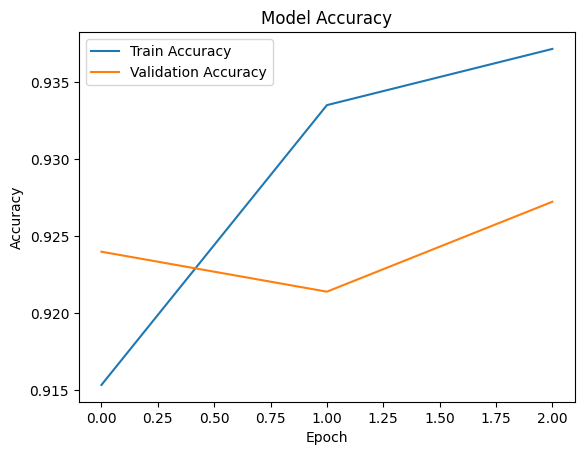

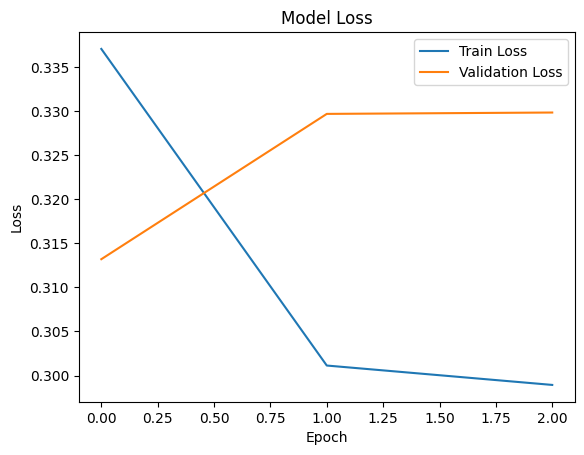

In [33]:
# Plot Accuracy

import matplotlib.pyplot as plt 
import seaborn as sns 

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Model Accuracy")
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Model Loss")
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

“The model achieved a validation accuracy of 92–93%, demonstrating strong performance on unseen customer review text. The training and validation accuracy remained close, indicating good generalization and minimal overfitting.”

In [35]:
from tensorflow.keras.models import load_model
import joblib

# Save Keras model
model.save("model.keras")     #TensorFlow 2.15+ has MANY bugs with .h5.

# Save vectorizers
joblib.dump(cv1, "cv1.pkl")   # i faced too many error in this part 🥲
joblib.dump(cv2, "cv2.pkl")   

print("✔ Model & vectorizers saved!")


✔ Model & vectorizers saved!


### This is for test the website

In [38]:
df['sentiment'].value_counts()

sentiment
1    25767
0     5079
Name: count, dtype: int64

In [36]:
df[df['sentiment']==0].head(10)

,review_headline,review_body,review_date,sentiment,headline_tokens,body_tokens,st1,st2,stem1,stem2,lemma1,lemma2,processed_head,processed_body
1,Lots of ads Slow processing speed Occasionally...,Lots of ads<br />Slow processing speed<br />Oc...,2015-08-31,0,"[Lots, of, ads, Slow, processing, speed, Occas...","[Lots, of, ads, <, br, /, >, Slow, processing,...","[lots, ads, slow, processing, speed, occasiona...","[lots, ads, br, slow, processing, speed, br, o...","[lot, ad, slow, process, speed, occasion, shut...","[lot, ad, br, slow, process, speed, br, occasi...","[lot, ad, slow, processing, speed, occasionall...","[lot, ad, br, slow, processing, speed, br, occ...",lot ad slow processing speed occasionally shut...,lot ad br slow processing speed br occasionall...
20,Three Stars,Its a nice tablet but I was disappointed to se...,2015-08-31,0,"[Three, Stars]","[Its, a, nice, tablet, but, I, was, disappoint...","[three, stars]","[nice, tablet, disappointed, see, deliberately...","[three, star]","[nice, tablet, disappoint, see, deliber, made,...","[three, star]","[nice, tablet, disappointed, see, deliberately...",three star,nice tablet disappointed see deliberately made...
21,Don't waste your money on this tablet,Don't waste your money buying a kindle fire hd...,2015-08-31,0,"[Do, n't, waste, your, money, on, this, tablet]","[Do, n't, waste, your, money, buying, a, kindl...","[waste, money, tablet]","[waste, money, buying, kindle, fire, hd, bette...","[wast, money, tablet]","[wast, money, buy, kindl, fire, hd, better, bu...","[waste, money, tablet]","[waste, money, buying, kindle, fire, hd, bette...",waste money tablet,waste money buying kindle fire hd better buyin...
22,Same sloppy OS same glitches still no flash co...,Still just as slow and glitchy as the first ed...,2015-08-31,0,"[Same, sloppy, OS, same, glitches, still, no, ...","[Still, just, as, slow, and, glitchy, as, the,...","[sloppy, os, glitches, still, flash, compatabi...","[still, slow, glitchy, first, edition, fire, s...","[sloppi, os, glitch, still, flash, compat]","[still, slow, glitchi, first, edit, fire, stil...","[sloppy, o, glitch, still, flash, compatability]","[still, slow, glitchy, first, edition, fire, s...",sloppy o glitch still flash compatability,still slow glitchy first edition fire still fl...
25,Three Stars,Doesn't have as much space as I thought it has.,2015-08-31,0,"[Three, Stars]","[Does, n't, have, as, much, space, as, I, thou...","[three, stars]","[much, space, thought]","[three, star]","[much, space, thought]","[three, star]","[much, space, thought]",three star,much space thought
27,Three Stars,Just have to learn how to use,2015-08-31,0,"[Three, Stars]","[Just, have, to, learn, how, to, use]","[three, stars]","[learn, use]","[three, star]","[learn, use]","[three, star]","[learn, use]",three star,learn use
35,"Won't stay connected to the WiFi, am having to...","Won't stay connected to the WiFi, am having to...",2015-08-31,0,"[Wo, n't, stay, connected, to, the, WiFi, ,, a...","[Wo, n't, stay, connected, to, the, WiFi, ,, a...","[wo, stay, connected, wifi]","[wo, stay, connected, wifi, constantly, log, m...","[wo, stay, connect, wifi]","[wo, stay, connect, wifi, constantli, log, mat...","[wo, stay, connected, wifi]","[wo, stay, connected, wifi, constantly, log, m...",wo stay connected wifi,wo stay connected wifi constantly log matter p...
36,The unit came with NO directions of use of any...,The unit came with NO directions of use of any...,2015-08-31,0,"[The, unit, came, with, NO, directions, of, us...","[The, unit, came, with, NO, directions, of, us...","[unit, came, directions, use]","[unit, came, directions, use, kind, know, use,...","[unit, came, direct, use]","[unit, came, direct, use, kind, know, use, gue...","[unit, came, direction, use]","[unit, came, direction, use, kind, know, use, ...",unit came direction use,unit came direction use kind know use guess bu...
40,Three Stars,Good value but the operating system is a littl...,2015-08-31,0,"[T

In [37]:
df[df['sentiment']==1].head(10)

,review_headline,review_body,review_date,sentiment,headline_tokens,body_tokens,st1,st2,stem1,stem2,lemma1,lemma2,processed_head,processed_body
0,Five Stars,Great love it,2015-08-31,1,"[Five, Stars]","[Great, love, it]","[five, stars]","[great, love]","[five, star]","[great, love]","[five, star]","[great, love]",five star,great love
2,Well thought out device,Excellent unit. The versatility of this table...,2015-08-31,1,"[Well, thought, out, device]","[Excellent, unit, ., The, versatility, of, thi...","[well, thought, device]","[excellent, unit, versatility, tablet, besides...","[well, thought, devic]","[excel, unit, versatil, tablet, besid, competi...","[well, thought, device]","[excellent, unit, versatility, tablet, besides...",well thought device,excellent unit versatility tablet besides comp...
3,Not all apps/games we were looking forward to ...,I bought this on Amazon Prime so I ended up bu...,2015-08-31,1,"[Not, all, apps/games, we, were, looking, forw...","[I, bought, this, on, Amazon, Prime, so, I, en...","[looking, forward, using, compatible, tablet, ...","[bought, amazon, prime, ended, buying, one, ca...","[look, forward, use, compat, tablet, enjoy, th...","[bought, amazon, prime, end, buy, one, camera,...","[looking, forward, using, compatible, tablet, ...","[bought, amazon, prime, ended, buying, one, ca...",looking forward using compatible tablet enjoyi...,bought amazon prime ended buying one camera ok...
4,Five Stars,All Amazon products continue to meet my expect...,2015-08-31,1,"[Five, Stars]","[All, Amazon, products, continue, to, meet, my...","[five, stars]","[amazon, products, continue, meet, expectations]","[five, star]","[amazon, product, continu, meet, expect]","[five, star]","[amazon, product, continue, meet, expectation]",five star,amazon product continue meet expectation
5,Four Stars,Good product. I like it 😀,2015-08-31,1,"[Four, Stars]","[Good, product, ., I, like, it, 😀]","[four, stars]","[good, product, like]","[four, star]","[good, product, like]","[four, star]","[good, product, like]",four star,good product like
6,Not a bad product. Simple. Works well. Nothing...,This kindle works well but the battery goes de...,2015-08-31,1,"[Not, a, bad, product, ., Simple, ., Works, we...","[This, kindle, works, well, but, the, battery,...","[bad, product, simple, works, well, nothing, f...","[kindle, works, well, battery, goes, dead, qui...","[bad, product, simpl, work, well, noth, fanci]","[kindl, work, well, batteri, goe, dead, quickl...","[bad, product, simple, work, well, nothing, fa...","[kindle, work, well, battery, go, dead, quickl...",bad product simple work well nothing fancy,kindle work well battery go dead quickly expec...
7,Five Stars,"I really enjoy my new kindle, it is easy to us...",2015-08-31,1,"[Five, Stars]","[I, really, enjoy, my, new, kindle, ,, it, is,...","[five, stars]","[really, enjoy, new, kindle, easy, use, offers...","[five, star]","[realli, enjoy, new, kindl, easi, use, offer, ...","[five, star]","[really, enjoy, new, kindle, easy, use, offer,...",five star,really enjoy new kindle easy use offer plenty ...
8,"Everything works great, the menu system is awful",It's what I wanted and performs perfectly. Eve...,2015-08-31,1,"[Everything, works, great, ,, the, menu, syste...","[It, 's, what, I, wanted, and, performs, perfe...","[everything, works, great, menu, system, awful]","[wanted, performs, perfectly, everything, work...","[everyth, work, great, menu, system, aw]","[want, perform, perfectli, everyth, work, grea...","[everything, work, great, menu, system, awful]","[wanted, performs, perfectly, everything, work...",everything work great menu system awful,wanted performs perfectly everything work grea...
9,Like looks and,Made well. Like looks and style,2015-08-31,1,"[Like, looks, and]","[Made, well, ., Like, looks, and, style]","[like, looks]","[made, well, like, looks, style]","[like, look]","[made, well, like, look, style]","[like, look]","[made, well, like, look, style]",like look,made

### For example
✅ Positive Reviews

- Headline: Amazing Camera Quality!
Body: The smartphone’s camera captures sharp, vibrant photos even in low light. Perfect for travel memories.

- Headline: Comfortable Office Chair
Body: I can sit for hours without back pain. The cushioning and adjustable height make it ideal for long workdays.

- Headline: Fast and Reliable Laptop
Body: Boots up in seconds and handles multiple applications smoothly. Great for both work and entertainment.

- Headline: Stylish Watch with Great Battery Life
Body: The design is sleek, and the battery lasts over a week. It’s both fashionable and functional.

- Headline: Excellent Noise-Cancelling Headphones
Body: Blocks out background noise completely. Sound quality is rich, and they’re comfortable for long flights.



### For example

❌ Negative Reviews

- Headline: Battery Dies Too Quickly
Body: The phone barely lasts half a day even with light use. Very disappointing for the price.

- Headline: Uncomfortable Fit
Body: These earbuds hurt my ears after 30 minutes. The design doesn’t suit everyone.

- Headline: Slow Performance
Body: The laptop lags even with basic tasks like browsing. Not worth the investment.

- Headline: Fragile Build Quality
Body: The blender worked fine for a week, then the motor burned out. Feels cheaply made.

- Headline: Misleading Product Description
Body: The backpack looked spacious online, but in reality, it barely fits a laptop. Very poor value.


## Project Completed Succesfully